**Business Question:** How can Airbnb optimise pricing strategies across NYC based on location, property characteristics and availability patterns, and what actionable listing segments can be identified using clustering techniques?

---
**Phase 1 Objectives:**
- Understand the raw dataset structure
- Handle missing values and outliers
- Engineer features for regression and clustering
- Produce EDA visualisations

> ⚠️ **Before running:** Make sure `AB_NYC_2019.csv` is in the **same folder** as this notebook.

---
## 1. Import Libraries

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.1 MB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.4 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 13.4 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 1.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 1.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 1.2 MB/s eta 0:00:00m eta 0:00:010:00:010m
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━

---
## 2. Load the Raw Dataset_First Look

In [3]:
#make sure the CSV is in the same folder as this notebook
df = pd.read_csv('AB_NYC_2019.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dataset shape: 48,895 rows × 16 columns
Memory usage: 22.3 MB


In [5]:
# First look — what does the data look like?
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.75,-73.97,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.69,-73.96,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76,-73.98,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80,-73.97,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71,-73.99,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [6]:
# Column data types
df.dtypes

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

---
## 3. Initial Dataset Audit
### 3a. Missing Values

In [7]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('Columns with missing values:')
print(missing.to_string())

Columns with missing values:
                   Missing Count  Missing %
last_review                10052      20.56
reviews_per_month          10052      20.56
host_name                     21       0.04
name                          16       0.03


> **Interpretation:**
> `last_review` and `reviews_per_month` share the same 10,052 missing rows : these are listings that have **never received a review**. This is structural missingness (not random), so removing them makes no sense. To be handled in the cleaning section.
> `name` and `host_name` have small missingness (16 and 21 rows) and aren't needed for modelling.

### 3b. Descriptive Statistics

In [8]:
# Numerical columns
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,38843.00,48895.00,48895.00
mean,19017143.24,67620010.65,40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,10983108.39,78610967.03,0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,2539.00,2438.00,40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,9471945.00,7822033.00,40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,19677284.00,30793816.00,40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,29152178.50,107434423.00,40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,36487245.00,274321313.00,40.91,-73.71,10000.00,1250.00,629.00,58.50,327.00,365.00


In [10]:
# Categorical columns
for col in ['neighbourhood_group', 'room_type', 'neighbourhood']:
    print(f'\n{"=" * 50}')
    print(f'  {col}')
    print(f'{"=" * 50}')
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    summary = pd.concat([vc, pct.rename('%')], axis=1)
    # For neighbourhood, only show top 20
    if col == 'neighbourhood':
        print(f'  (Showing top 20 of {df[col].nunique()} unique values)')
        print(summary.head(20).to_string())
    else:
        print(summary.to_string())


  neighbourhood_group
                     count     %
neighbourhood_group             
Manhattan            21661 44.30
Brooklyn             20104 41.10
Queens                5666 11.60
Bronx                 1091  2.20
Staten Island          373  0.80

  room_type
                 count     %
room_type                   
Entire home/apt  25409 52.00
Private room     22326 45.70
Shared room       1160  2.40

  neighbourhood
  (Showing top 20 of 221 unique values)
                    count    %
neighbourhood                 
Williamsburg         3920 8.00
Bedford-Stuyvesant   3714 7.60
Harlem               2658 5.40
Bushwick             2465 5.00
Upper West Side      1971 4.00
Hell's Kitchen       1958 4.00
East Village         1853 3.80
Upper East Side      1798 3.70
Crown Heights        1564 3.20
Midtown              1545 3.20
East Harlem          1117 2.30
Greenpoint           1115 2.30
Chelsea              1113 2.30
Lower East Side       911 1.90
Astoria               900 1.80
Wash

>**Interpretation:**
>`neighbourhood_group`, `room_type` and `neighbourhood` were selected as they directly address location and property characteristics in the business question. `name` and `host_name` are excluded as free-text fields unsuitable for regression or clustering. 
>Note for modelling: `neighbourhood` has 221 unique values and will require target encoding (its median price) rather than one-hot encoding in the modelling phase to avoid creating 221 dummy columns.(OPTIONALLY, it can be removed)

### 3c. Price Investigation

In [16]:
print('=== Price Distribution ===')
print(df['price'].describe())
print(f'\nZero-price listings:      {(df["price"] == 0).sum()}')
print(f'Listings priced > $1,000: {(df["price"] > 1000).sum()}')
print(f'Listings priced > $2,000: {(df["price"] > 2000).sum()}')
print(f'Maximum price:            ${df["price"].max():,}')

# Show the most expensive listings
print('\n--- Top 10 Most Expensive Listings ---')
df[['neighbourhood_group','neighbourhood','room_type','price',
    'number_of_reviews','availability_365']].nlargest(10, 'price')

=== Price Distribution ===
count   48895.00
mean      152.72
std       240.15
min         0.00
25%        69.00
50%       106.00
75%       175.00
max     10000.00
Name: price, dtype: float64

Zero-price listings:      11
Listings priced > $1,000: 239
Listings priced > $2,000: 86
Maximum price:            $10,000

--- Top 10 Most Expensive Listings ---


,neighbourhood_group,neighbourhood,room_type,price,number_of_reviews,availability_365
9151,Queens,Astoria,Private room,10000,2,0
17692,Brooklyn,Greenpoint,Entire home/apt,10000,5,0
29238,Manhattan,Upper West Side,Entire home/apt,10000,0,83
6530,Manhattan,East Harlem,Entire home/apt,9999,1,0
12342,Manhattan,Lower East Side,Private room,9999,6,83
40433,Manhattan,Lower East Side,Entire home/apt,9999,0,365
30268,Manhattan,Tribeca,Entire home/apt,8500,2,251
4377,Brooklyn,Clinton Hill,Entire home/apt,8000,1,365
29662,Manhattan,Upper East Side,Entire home/apt,7703,0,146
42523,Manhattan,Battery Park City,Entire home/apt,7500,0,364


>**Interpretation:**
>the `availability_365 = 0`, is ambiguous: it could mean:
>Very popular and fully booked 
>Deliberately blocked by host 
>Inactive listing 
>I suggest noting it as limitation of the dataset in the report, because we cannot distinguish between a genuinely booked listing and a blocked one from this data alone.

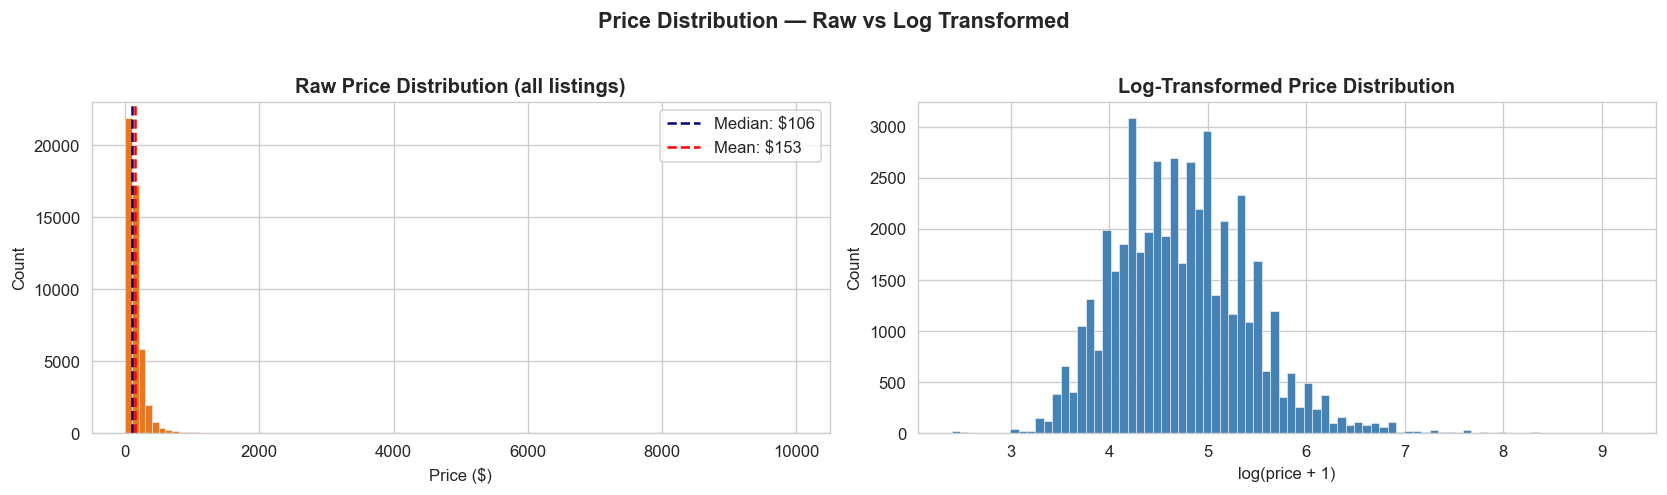


💡 Notice: Log transformation converts the heavily right-skewed distribution
   into an approximately normal one, better for linear regression.


In [18]:
# Visualise the raw price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw price
axes[0].hist(df['price'], bins=100, color='#E87722', edgecolor='white', linewidth=0.3)
axes[0].set_title('Raw Price Distribution (all listings)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(), color='navy', linestyle='--', 
                label=f'Median: ${df["price"].median():.0f}')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--',
                label=f'Mean: ${df["price"].mean():.0f}')
axes[0].legend()

# Log-transformed price
df_nonzero = df[df['price'] > 0]
axes[1].hist(np.log1p(df_nonzero['price']), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Price Distribution — Raw vs Log Transformed', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Notice: Log transformation converts the heavily right-skewed distribution')
print('   into an approximately normal one, better for linear regression.')

> **Decision: Log Price as Target Variable:**
> The rar price is obvisouly heavily skewed due to the high price outliers for luxury listing. Rather than limiting the price in the dataset at threshold (e.g. $1,000), we apply a **log transformation** to the price variable. This preserves all listings including the luxury ones ( important for our main busines analytic question), while compressing the influence of extreme values on the regression model. This is standard practice in real estate and rental pricing models.
> NOTE: The model will predict `log(price)`, and results can be converted back with `expm1` back to USD.

### 3d. Minimum Nights Investigation

In [19]:
print('=== Minimum Nights ===')
print(df['minimum_nights'].describe())
print(f'\nListings with minimum_nights > 365: {(df["minimum_nights"] > 365).sum()}')
print(f'Listings with minimum_nights > 30:  {(df["minimum_nights"] > 30).sum()}')

# Show extreme cases
print('\n--- Listings with minimum_nights > 365 ---')
df[df['minimum_nights'] > 365][['neighbourhood_group','room_type','price',
                                  'minimum_nights','availability_365']].head(10)

=== Minimum Nights ===
count   48895.00
mean        7.03
std        20.51
min         1.00
25%         1.00
50%         3.00
75%         5.00
max      1250.00
Name: minimum_nights, dtype: float64

Listings with minimum_nights > 365: 14
Listings with minimum_nights > 30:  747

--- Listings with minimum_nights > 365 ---


,neighbourhood_group,room_type,price,minimum_nights,availability_365
1305,Brooklyn,Entire home/apt,115,370,365
2854,Manhattan,Entire home/apt,400,1000,362
5767,Manhattan,Entire home/apt,180,1250,365
7355,Queens,Entire home/apt,134,500,90
8014,Manhattan,Entire home/apt,75,500,362
10829,Queens,Entire home/apt,199,480,365
11193,Brooklyn,Private room,50,500,365
13404,Manhattan,Entire home/apt,99,999,42
14285,Brooklyn,Private room,45,500,358
15946,Manhattan,Entire home/apt,250,366,365


> **Decision:** Listings with `minimum_nights > 365` are operationally impossible for a short-term rental platform like Airnbb and likely data entry errors. Max capped at 365.

---
## 4. Exploratory Data Analysis
### 4a. Price by Borough and Room Type

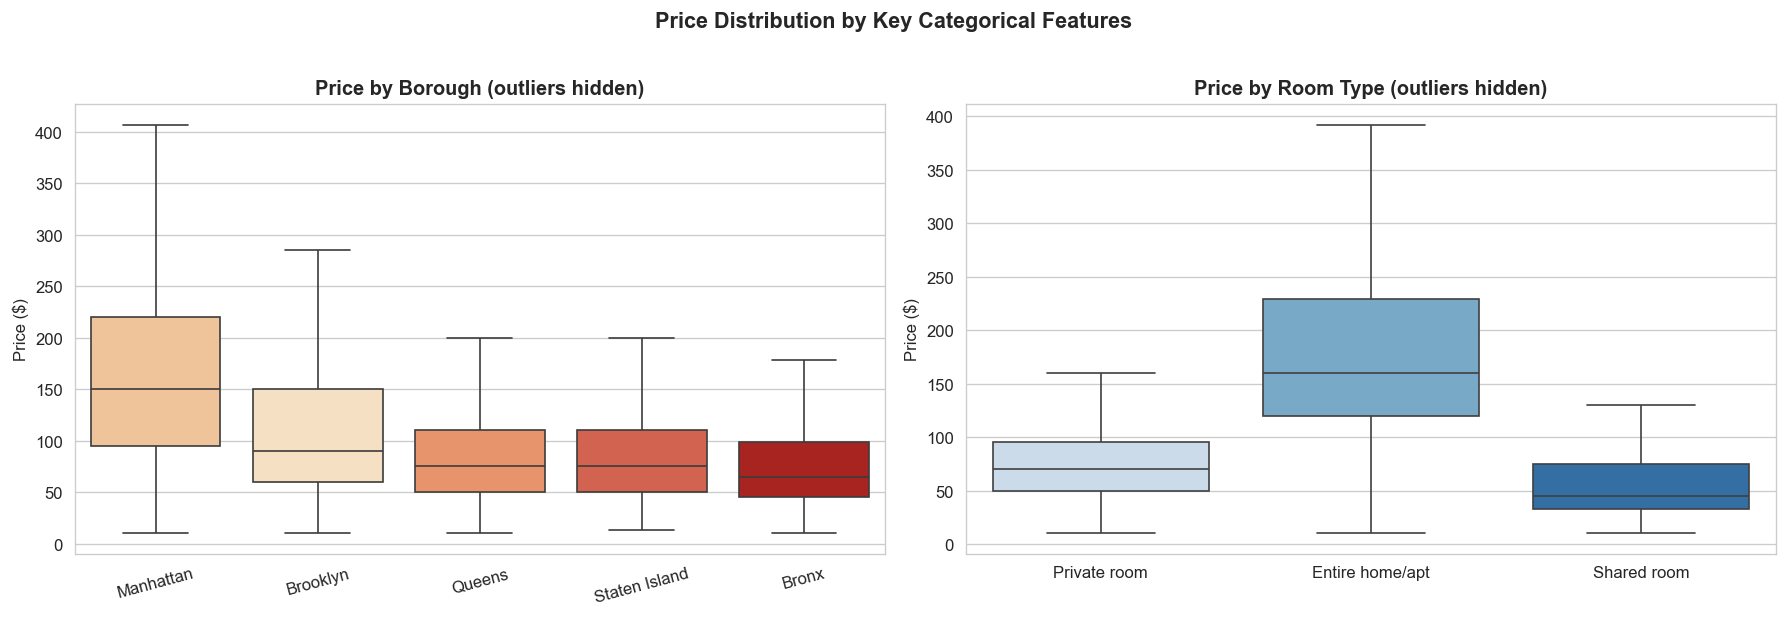

In [22]:
# Work on a filtered view (price > 0) for EDA visualisations
df_eda = df[df['price'] > 0].copy()

borough_order = df_eda.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot by borough
sns.boxplot(data=df_eda, x='neighbourhood_group', y='price', order=borough_order,
            showfliers=False, ax=axes[0], palette='OrRd',
            hue='neighbourhood_group', legend=False)
axes[0].set_title('Price by Borough (outliers hidden)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Price ($)')
axes[0].tick_params(axis='x', rotation=15)

# Boxplot by room type
sns.boxplot(data=df_eda, x='room_type', y='price', showfliers=False,
            ax=axes[1], palette='Blues',
            hue='room_type', legend=False)
axes[1].set_title('Price by Room Type (outliers hidden)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Price ($)')

plt.suptitle('Price Distribution by Key Categorical Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_price_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

> **Visualisation Decision:**
> Outliers are suppressed in boxplot visualisations for readability, however they are retained in the dataset and handled via log transformation rather than removal. If you want to see them inncluding the outlier dots, change 'showfliers=False' to True 


### 4b. Median Price Heatmap : Borough × Room Type

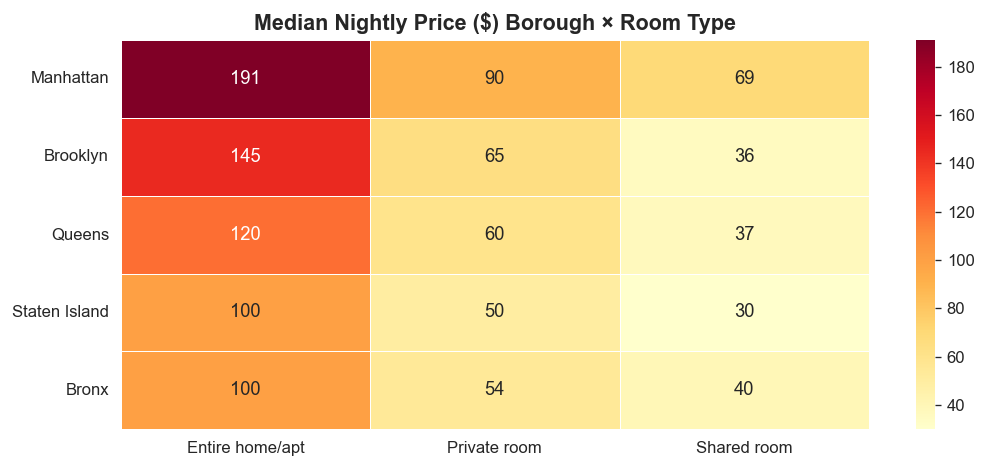


--- Median prices by Borough × Room Type ---
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Manhattan                     191.00         90.00        69.00
Brooklyn                      145.00         65.00        36.00
Queens                        120.00         60.00        37.00
Staten Island                 100.00         50.00        30.00
Bronx                         100.00         54.00        40.00


In [24]:
pivot = df_eda.pivot_table(values='price', index='neighbourhood_group',
                           columns='room_type', aggfunc='median')
# Reorder rows by overall median
pivot = pivot.loc[borough_order]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, annot_kws={'size': 11})
ax.set_title('Median Nightly Price ($) Borough × Room Type', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plot_heatmap_price.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Median prices by Borough × Room Type ---')
print(pivot.to_string())

### 4c. Geographical Price Distribution

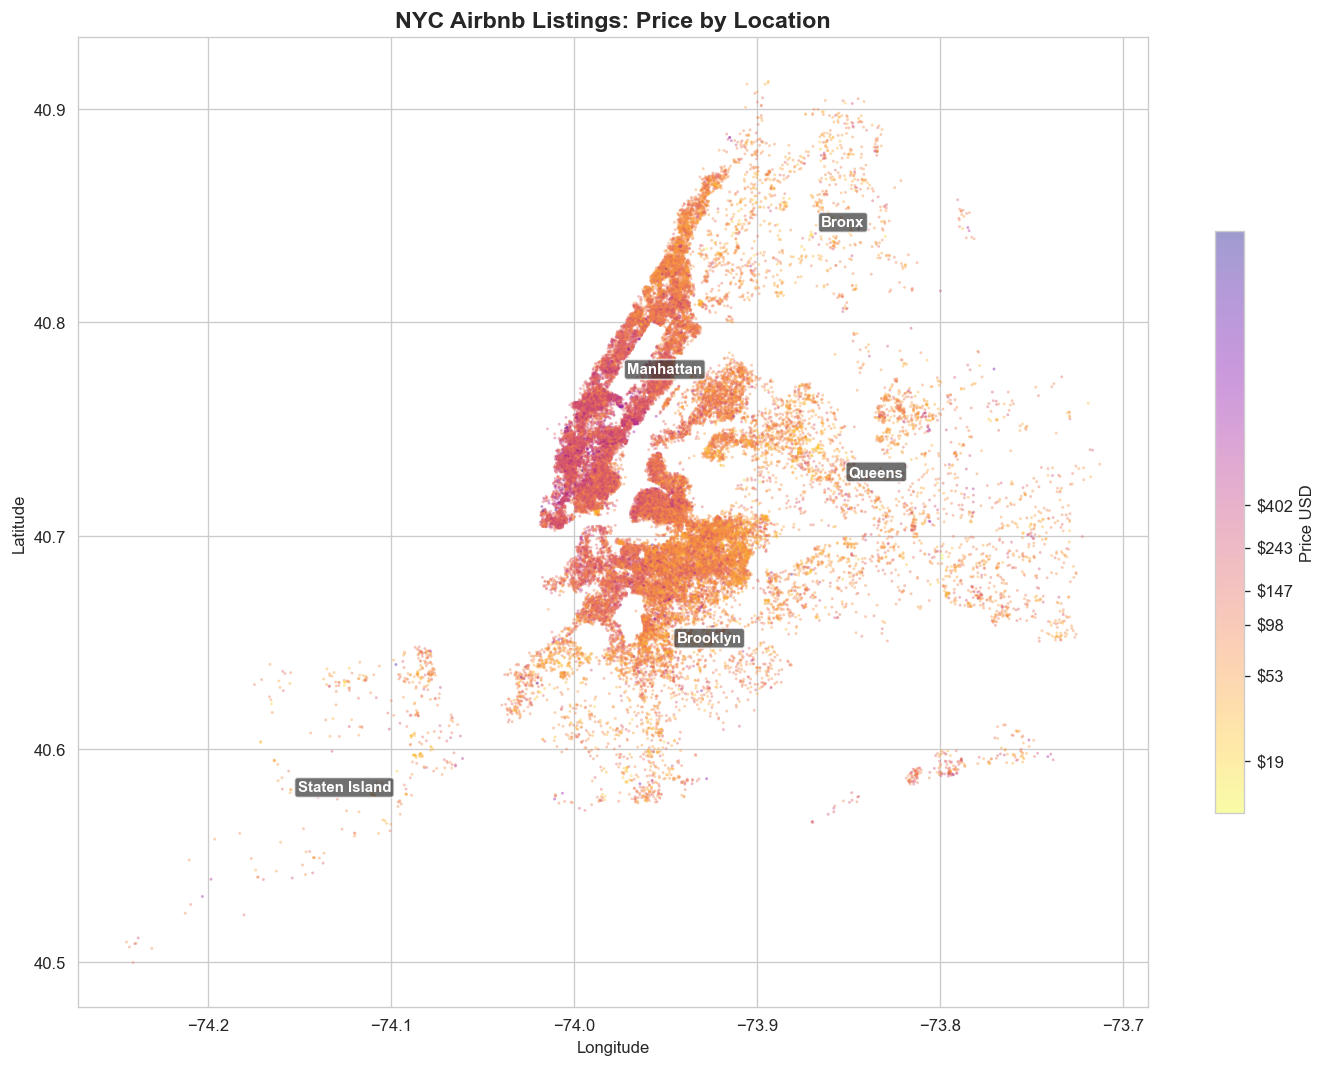

In [27]:
# Scatter map coloured by log price
fig, ax = plt.subplots(figsize=(12, 9))

sc = ax.scatter(
    df_eda['longitude'],
    df_eda['latitude'],
    c=np.log1p(df_eda['price']),
    cmap='plasma_r',
    alpha=0.4,
    s=3,
    linewidths=0
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label('Price USD', fontsize=10)
# Annotate colour bar ticks with real prices
tick_vals = [3, 4, 4.6, 5, 5.5, 6]
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f'${int(np.expm1(v))}' for v in tick_vals])

ax.set_title('NYC Airbnb Listings: Price by Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Borough labels
borough_coords = {
    'Manhattan':    (-73.971, 40.776),
    'Brooklyn':     (-73.944, 40.650),
    'Queens':       (-73.850, 40.728),
    'Bronx':        (-73.865, 40.845),
    'Staten Island':(-74.151, 40.580)
}
for name, (lon, lat) in borough_coords.items():
    ax.text(lon, lat, name, fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#333333', alpha=0.7))

plt.tight_layout()
plt.savefig('plot_geo_price.png', dpi=150, bbox_inches='tight')
plt.show()

> **Visualisation Decision:**
> Each dot is one listing positioned by GPS coordinates. Colour runs 
from yellow (cheap) to dark purple (expensive) using a reversed 
plasma scale( in my opinion the original plasma flow looks nicer but the reversed plasma shows the cheap to expensive plasma better and also follows the heatmap colours schme and onsistency across the visualisations is something that Steph will notice and it's part of our Structure and Presentation mark which is worth 20%). Log1p transformation is applied to price before 
colouring and compressing the scale so that luxury outliers do not dominate and variation across the majority of listings remains 
visible.


### 4d. Availability and Review Patterns

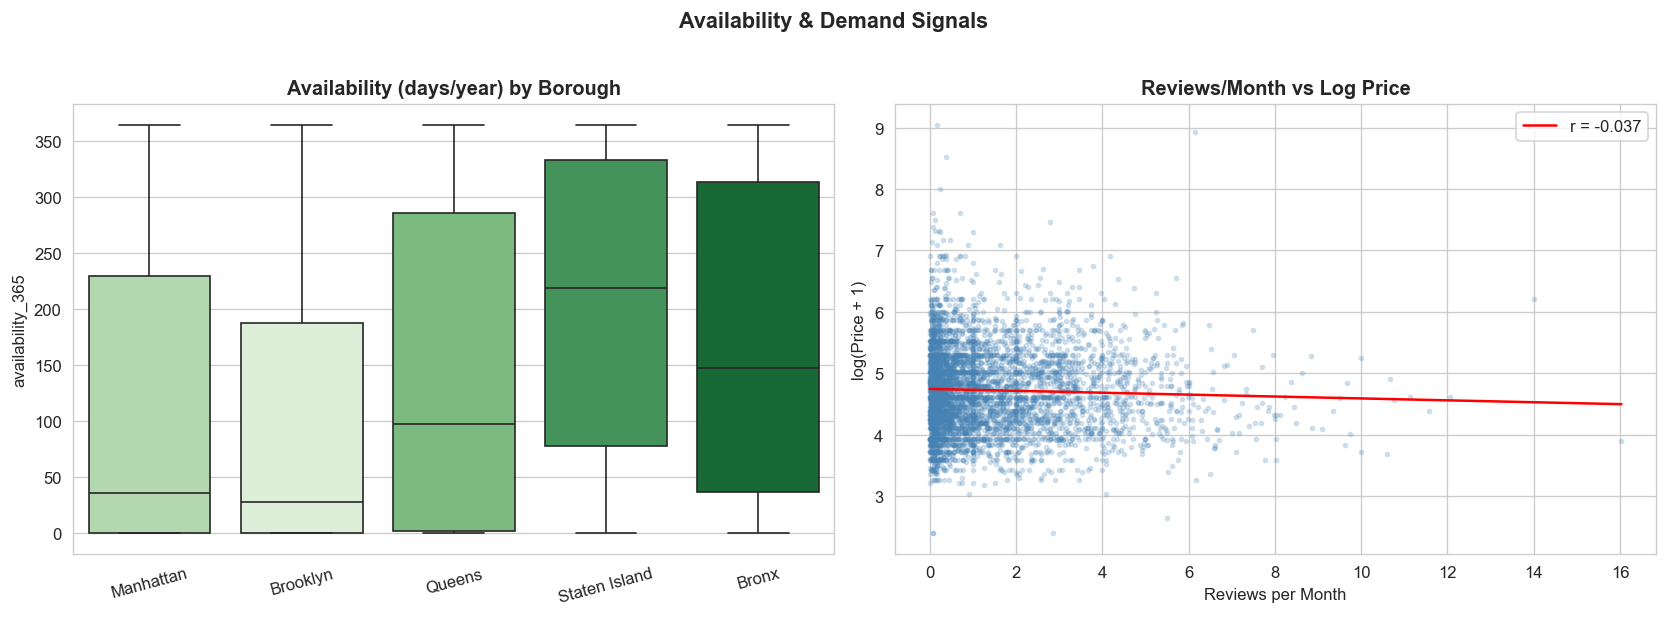

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Availability by borough
sns.boxplot(data=df_eda, x='neighbourhood_group', y='availability_365',
            order=borough_order, showfliers=False, ax=axes[0],
            hue='neighbourhood_group', palette='Greens', legend=False)
axes[0].set_title('Availability (days/year) by Borough', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Reviews per month vs price
sample = df_eda[df_eda['reviews_per_month'].notna()].sample(5000, random_state=42)
axes[1].scatter(sample['reviews_per_month'], np.log1p(sample['price']),
                alpha=0.2, s=6, color='steelblue')
axes[1].set_title('Reviews/Month vs Log Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Reviews per Month')
axes[1].set_ylabel('log(Price + 1)')
# Trend line
m, b, r, p, _ = stats.linregress(sample['reviews_per_month'], np.log1p(sample['price']))
x_line = np.linspace(0, sample['reviews_per_month'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=1.5,
             label=f'r = {r:.3f}')
axes[1].legend()

plt.suptitle('Availability & Demand Signals', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_availability_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

>**Interpretation:**
> The leftboxplot showing how many days per year listings in each borough are available for booking. This answers a key business question: **Are certain boroughs more actively managed than others?** A low availability could mean either very popular (fully booked) or heavily blocked by hosts, which links back to the ambiguity we discussed earlier with `availability_365 = 0`.
>On left, the r value shown in the legend is the correlation coefficient, how strongly the two variables are related. r = -0.037 , very weak negative relationship, so almost no relationship at all really. So more reviews per month tend to be very slightly cheaper, but the relationship is so weak that you can't really draw strong conclusions from it alone.

### 4e. Room Type Mix by Borough

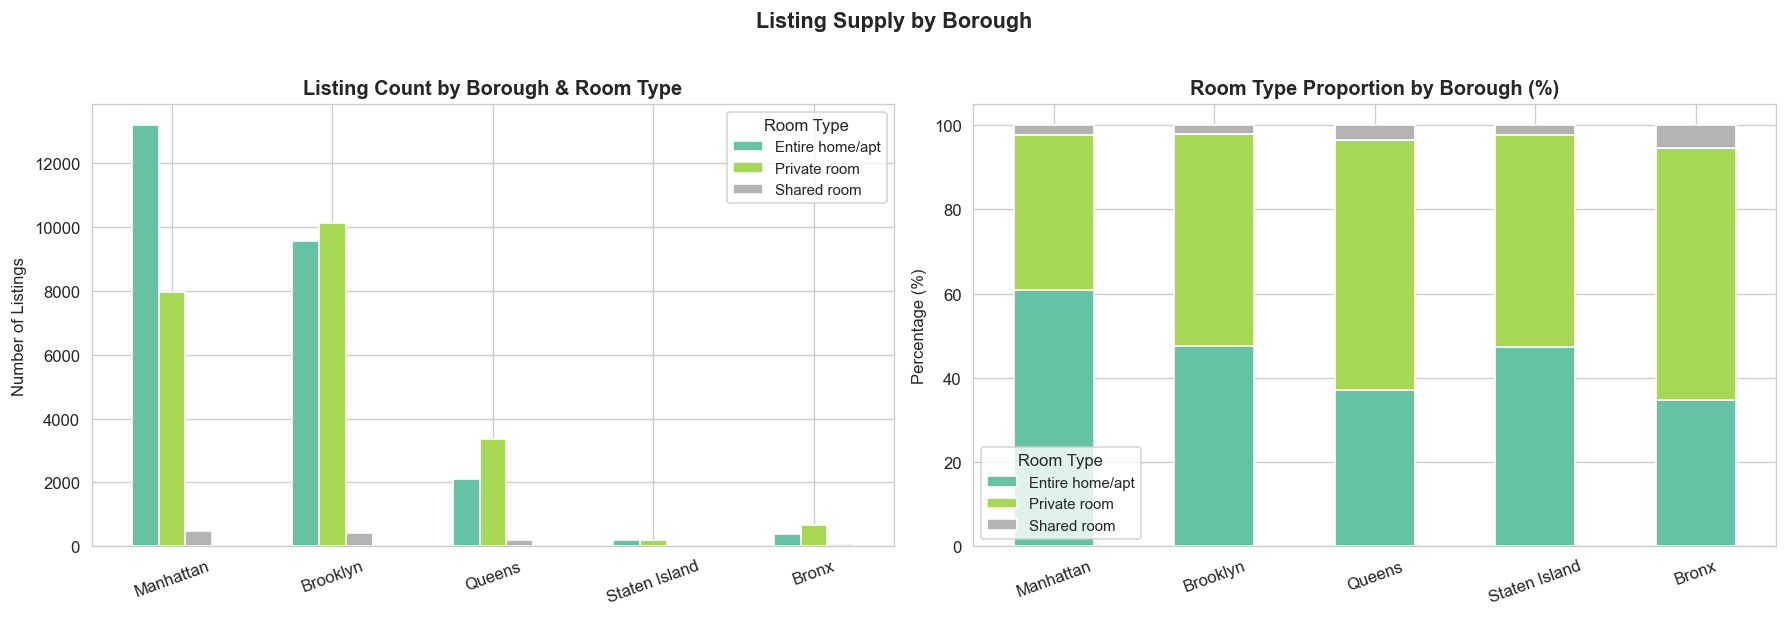

In [29]:
ct = df_eda.groupby(['neighbourhood_group','room_type']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absolute counts
ct.loc[borough_order].plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Listing Count by Borough & Room Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Listings')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Room Type', fontsize=9)

# Proportional
ct_pct.loc[borough_order].plot(kind='bar', stacked=True, ax=axes[1],
                               colormap='Set2', edgecolor='white')
axes[1].set_title('Room Type Proportion by Borough (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Room Type', fontsize=9)

plt.suptitle('Listing Supply by Borough', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_room_type_mix.png', dpi=150, bbox_inches='tight')
plt.show()

### 4f. Correlation Matrix

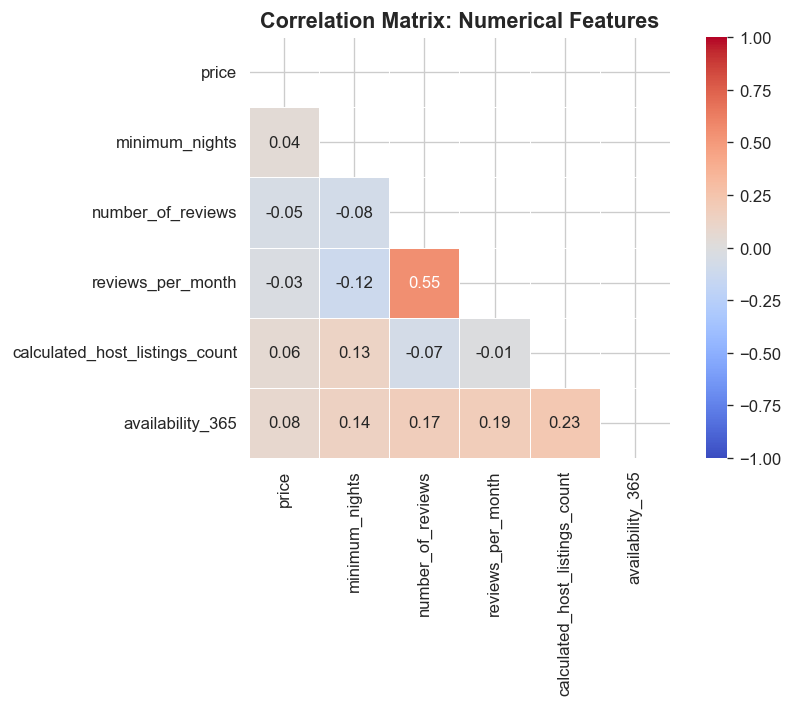


--- Correlations with Price ---
price                             1.00
availability_365                  0.08
calculated_host_listings_count    0.06
minimum_nights                    0.04
reviews_per_month                -0.03
number_of_reviews                -0.05


In [31]:
num_cols = ['price', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

corr = df_eda[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, annot_kws={'size': 10},
            vmin=-1, vmax=1, center=0, square=True)
ax.set_title('Correlation Matrix: Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Correlations with Price ---')
print(corr['price'].sort_values(ascending=False).to_string())

>**Interpretation:**
> The row/column we care most about is price and which features correlate most strongly with it. From the data the correlations with price are very weak across all **numerical features**, which tells you that:

>**Categorical features (borough, room type) are likely the real price drivers.**
The numerical features will contribute more to clustering than price prediction.

---
## 5. Data Cleaning
All decisions are documented with rationale.

In [32]:
# Start with a fresh copy of the raw data
df_clean = df.copy()
print(f'Starting rows: {len(df_clean):,}')

Starting rows: 48,895


### 5a. Remove Zero-Price Listings

In [33]:
# DECISION: Remove price == 0 since a listing cannot be free; so it must be data entry errors.
# We do NOT cap the upper limit to include luxury rentals, instead we use log transformation.
before = len(df_clean)
df_clean = df_clean[df_clean['price'] > 0]
print(f'Removed {before - len(df_clean)} zero-price listings → {len(df_clean):,} remaining')

Removed 11 zero-price listings → 48,884 remaining


### 5b. Handle Missing Values

In [35]:
# DECISION: reviews_per_month: fill with 0
# Rationale: missing means no reviews have been left yet, so monthly rate is genuinely 0.
# Mean/median imputation would misrepresent inactive listings since it is not a missing random value.
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
print(f'Current reviews_per_month missing: {df_clean["reviews_per_month"].isnull().sum()}')

Current reviews_per_month missing: 0


In [37]:
# DECISION: last_review: convert to 'days since last review' and anchoring to December 2019 as the end of the data collection period.
# Rationale: a date column is not useful for ML directly.
# 'Days since review' is a continuous and a  feature that captures listing recency.
# Listings with no review get the median value (conservative estimate, not the max,
# which could be misleading since we don't know when they were listed).

ref_date = pd.Timestamp('2019-12-31')  # Reference: end of dataset period
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], errors='coerce')
df_clean['days_since_review'] = (ref_date - df_clean['last_review']).dt.days

median_days = df_clean['days_since_review'].median()
df_clean['days_since_review'] = df_clean['days_since_review'].fillna(median_days)

print(f'days_since_review median value: {median_days:.0f} days')
print(f'Currently Missing: {df_clean["days_since_review"].isnull().sum()}')

days_since_review median value: 226 days
Currently Missing: 0


In [38]:
# DECISION: name, host_name: drop columns
# Rationale: Free-text fields. Cannot be used in regression or clustering
# id and host_id are identifiers, not features.
cols_to_drop = ['name', 'host_name', 'last_review']  # id/host_id kept for traceability
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped columns: {cols_to_drop}')

Dropped columns: ['name', 'host_name', 'last_review']


### 5c. Cap Minimum Nights

In [39]:
# DECISION: Cap minimum_nights at 365
# Rationale: Values > 365 are operationally unsuitable for a short-term rental
before_cap = (df_clean['minimum_nights'] > 365).sum()
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=365)
print(f'Capped {before_cap} listings with minimum_nights > 365')

Capped 14 listings with minimum_nights > 365


---
## 6. Feature Engineering

In [41]:
# --- LOG PRICE (Target Variable for Regression) ---
# Rationale: Price is right-skewed. Log transformation normalises the distribution,
# stabilises variance, and ensures luxury listings don't dominate the model.
df_clean['log_price'] = np.log1p(df_clean['price'])  # log1p = log(price + 1), safe for price=0

# --- AVAILABILITY RATIO ---
# Rationale: More interpretable as a proportion (0 = never available, 1 = always).
# Better for clustering than raw days count.
df_clean['availability_ratio'] = df_clean['availability_365'] / 365

# --- MULTI-HOST FLAG ---
# Rationale: Hosts with multiple listings tend to be professional operators.
# They may apply systematic pricing strategies different from casual hosts and should be taken into account.
df_clean['is_multi_host'] = (df_clean['calculated_host_listings_count'] > 1).astype(int)

# --- HAS REVIEWS FLAG ---
# Rationale: Reviewed listings have social proof. Yes/No flag captures this
# without introducing the skew of raw review counts. Meaning the listing has established itself in the market, which is more meaningful for both regression and clustering than the raw count.
df_clean['has_reviews'] = (df_clean['number_of_reviews'] > 0).astype(int)

print('Feature engineering complete')
print(f'\nNew features added: log_price, availability_ratio, is_multi_host, has_reviews')
print(f'Final column list:')
for i, col in enumerate(df_clean.columns, 1):
    print(f'  {i:2d}. {col}')

Feature engineering complete

New features added: log_price, availability_ratio, is_multi_host, has_reviews
Final column list:
   1. id
   2. host_id
   3. neighbourhood_group
   4. neighbourhood
   5. latitude
   6. longitude
   7. room_type
   8. price
   9. minimum_nights
  10. number_of_reviews
  11. reviews_per_month
  12. calculated_host_listings_count
  13. availability_365
  14. days_since_review
  15. log_price
  16. availability_ratio
  17. is_multi_host
  18. has_reviews


---
## 7. Final Dataset Validation

In [42]:
print('=== FINAL DATASET SUMMARY ===')
print(f'Rows:    {len(df_clean):,}')
print(f'Columns: {len(df_clean.columns)}')
print(f'\nMissing values after cleaning:')
missing_final = df_clean.isnull().sum()
if missing_final.sum() == 0:
    print('  No missing values — dataset is clean')
else:
    print(missing_final[missing_final > 0])

print(f'\nPrice range: ${df_clean["price"].min()} – ${df_clean["price"].max():,}')
print(f'Median price: ${df_clean["price"].median():.0f}')
print(f'Mean price:   ${df_clean["price"].mean():.0f}')

=== FINAL DATASET SUMMARY ===
Rows:    48,884
Columns: 18

Missing values after cleaning:
  No missing values — dataset is clean

Price range: $10 – $10,000
Median price: $106
Mean price:   $153


In [43]:
# Preview the cleaned dataset
df_clean.head(10)

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_review,log_price,availability_ratio,is_multi_host,has_reviews
0,2539,2787,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,0.21,6,365,438.00,5.01,1.00,1,1
1,2595,2845,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,0.38,2,355,224.00,5.42,0.97,1,1
2,3647,4632,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,0.00,1,365,226.00,5.02,1.00,0,0
3,3831,4869,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,4.64,1,194,179.00,4.50,0.53,0,1
4,5022,7192,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,0.10,1,0,407.00,4.39,0.00,0,1
5,5099,7322,Manhattan,Murray Hill,40.75,-73.97,Entire home/apt,200,3,74,0.59,1,129,192.00,5.30,0.35,0,1
6,5121,7356,Brooklyn,Bedford-Stuyvesant,40.69,-73.96,Private room,60,45,49,0.40,1,0,817.00,4.11,0.00,0,1
7,5178,8967,Manhattan,Hell's Kitchen,40.76,-73.98,Private room,79,2,430,3.47,1,220,190.00,4.38,0.60,0,1
8,5203,7490,Manhattan,Upper West Side,40.80,-73.97,Private room,79,2,118,0.99,1,0,893.00,4.38,0.00,0,1
9,5238,7549,Manhattan,Chinatown,40.71,-73.99,Entire home/apt,150,1,160,1.33,4,188,205.00,5.02,0.52,1,1


In [44]:
# Descriptive statistics of cleaned numerical features
df_clean.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_review,log_price,availability_ratio,is_multi_host,has_reviews
count,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00
mean,19016793.41,67622034.56,40.73,-73.95,152.76,6.94,23.27,1.09,7.14,112.78,406.29,4.74,0.31,0.34,0.79
std,10984315.04,78616662.30,0.05,0.05,240.17,17.53,44.55,1.60,32.96,131.63,380.18,0.69,0.36,0.47,0.40
min,2539.00,2438.00,40.50,-74.24,10.00,1.00,0.00,0.00,1.00,0.00,176.00,2.40,0.00,0.00,0.00
25%,9470547.50,7817310.25,40.69,-73.98,69.00,1.00,1.00,0.04,1.00,0.00,195.00,4.25,0.00,0.00,1.00
50%,19675740.50,30792573.50,40.72,-73.96,106.00,3.00,5.00,0.37,1.00,45.00,226.00,4.67,0.12,0.00,1.00
75%,29152966.75,107434423.00,40.76,-73.94,175.00,5.00,24.00,1.58,2.00,227.00,422.00,5.17,0.62,1.00,1.00
max,36487245.00,274321313.00,40.91,-73.71,10000.00,365.00,629.00,58.50,327.00,365.00,3200.00,9.21,1.00,1.00,1.00


---
## 8.Summary
### Features for Regression (Price Prediction)

In [46]:
feature_summary = pd.DataFrame([
    ('neighbourhood_group', 'Categorical', 'Borough-level location : strongest price predictor'),
    ('neighbourhood',       'Categorical', 'Granular location : use target encoding (median price per neighbourhood)'),
    ('latitude',            'Numerical',   'Continuous spatial feature : captures micro-location effects'),
    ('longitude',           'Numerical',   'Continuous spatial feature'),
    ('room_type',           'Categorical', 'Property type : second strongest price predictor'),
    ('minimum_nights',      'Numerical',   'Booking policy : may signal short-stay vs long-stay'),
    ('number_of_reviews',   'Numerical',   'Did it established itself in the market?'),
    ('reviews_per_month',   'Numerical',   'Demand velocity : how active the listing is'),
    ('availability_ratio',  'Numerical',   'Engineered : proportion of year listing is available'),
    ('days_since_review',   'Numerical',   'Engineered : recency of activity'),
    ('is_multi_host',       'Binary',      'Engineered : professional vs casual host flag'),
    ('has_reviews',         'Binary',      'Engineered : listing maturity proxy'),
    ('calculated_host_listings_count', 'Numerical', 'Host portfolio size'),
], columns=['Feature', 'Type', 'Rationale'])

print('=== FEATURES SELECTED FOR MODELLING ===')
print(feature_summary.to_string(index=False))

print('\n=== TARGET VARIABLE ===')
print('log_price — log-transformed price. Predict with regression, convert back with exp(prediction) - 1')

print('\n=== COLUMNS NOT USED IN MODELLING ===')
print('id, host_id — identifiers, not features')
print('availability_365 — replaced by availability_ratio')
print('price — replaced by log_price as model target')

=== FEATURES SELECTED FOR MODELLING ===
                       Feature        Type                                                                Rationale
           neighbourhood_group Categorical                       Borough-level location : strongest price predictor
                 neighbourhood Categorical Granular location : use target encoding (median price per neighbourhood)
                      latitude   Numerical             Continuous spatial feature : captures micro-location effects
                     longitude   Numerical                                               Continuous spatial feature
                     room_type Categorical                         Property type : second strongest price predictor
                minimum_nights   Numerical                      Booking policy : may signal short-stay vs long-stay
             number_of_reviews   Numerical                                 Did it established itself in the market?
             reviews_per_month  

---
## 9. Save Cleaned Dataset

In [47]:
output_filename = 'AB_NYC_2019_cleaned.csv'
df_clean.to_csv(output_filename, index=False)
print(f' Cleaned dataset saved as: {output_filename}')
print(f'   Rows: {len(df_clean):,} | Columns: {len(df_clean.columns)}')
print(f'\nPlots saved:')
for f in ['plot_price_distribution.png', 'plot_price_by_category.png',
          'plot_heatmap_price.png', 'plot_geo_price.png',
          'plot_availability_reviews.png', 'plot_room_type_mix.png',
          'plot_correlation.png']:
    print(f'   {f}')

 Cleaned dataset saved as: AB_NYC_2019_cleaned.csv
   Rows: 48,884 | Columns: 18

Plots saved:
   plot_price_distribution.png
   plot_price_by_category.png
   plot_heatmap_price.png
   plot_geo_price.png
   plot_availability_reviews.png
   plot_room_type_mix.png
   plot_correlation.png


---
## 10. Key EDA Findings Summary
*Find this section in the shared document "Key Findings & Analysis"*

In [48]:
print('=' * 65)
print('KEY EDA FINDINGS for Airbnb NYC 2019 Dataset')
print('=' * 65)

print(f"""
DATASET
  Raw:     {len(df):,} listings, 16 columns
  Cleaned: {len(df_clean):,} listings, {len(df_clean.columns)} columns
  Removed: {len(df) - len(df_clean):,} zero-price entries (data errors)

PRICE
  Median: ${df_clean['price'].median():.0f}/night
  Mean:   ${df_clean['price'].mean():.0f}/night (higher due to luxury listings)
  Range:  $10 – ${df_clean['price'].max():,}
  Distribution is right-skewed → log transformation applied for modelling

LOCATION
  Manhattan median: ${df_clean[df_clean['neighbourhood_group']=='Manhattan']['price'].median():.0f}/night
  Brooklyn median:  ${df_clean[df_clean['neighbourhood_group']=='Brooklyn']['price'].median():.0f}/night
  Queens median:    ${df_clean[df_clean['neighbourhood_group']=='Queens']['price'].median():.0f}/night
  Bronx median:     ${df_clean[df_clean['neighbourhood_group']=='Bronx']['price'].median():.0f}/night
  → Borough is the single strongest price driver

ROOM TYPE
  Entire home/apt: {(df_clean['room_type']=='Entire home/apt').sum():,} listings """
  f"({(df_clean['room_type']=='Entire home/apt').mean()*100:.0f}%) — highest priced"
)

print(f"""  Private room:    {(df_clean['room_type']=='Private room').sum():,} listings """
  f"({(df_clean['room_type']=='Private room').mean()*100:.0f}%) — mid-range"
)

print(f"""  Shared room:     {(df_clean['room_type']=='Shared room').sum():,} listings """
  f"({(df_clean['room_type']=='Shared room').mean()*100:.0f}%) — budget segment"
)

pct_no_review = (df_clean['has_reviews'] == 0).mean() * 100
pct_multi = df_clean['is_multi_host'].mean() * 100

print(f"""
MISSING VALUES
  reviews_per_month: 10,052 missing → filled with 0 (no reviews = zero rate)
  last_review: converted to days_since_review → missing filled with median

DEMAND SIGNALS
  {pct_no_review:.1f}% of listings have never received a review (inactive)
  {pct_multi:.1f}% of listings belong to multi-property hosts (professional operators)
  reviews_per_month has weak negative correlation with price (r ≈ -0.05)
  → Higher-priced listings book less frequently but earn more per stay

""")

KEY EDA FINDINGS for Airbnb NYC 2019 Dataset

DATASET
  Raw:     48,895 listings, 16 columns
  Cleaned: 48,884 listings, 18 columns
  Removed: 11 zero-price entries (data errors)

PRICE
  Median: $106/night
  Mean:   $153/night (higher due to luxury listings)
  Range:  $10 – $10,000
  Distribution is right-skewed → log transformation applied for modelling

LOCATION
  Manhattan median: $150/night
  Brooklyn median:  $90/night
  Queens median:    $75/night
  Bronx median:     $65/night
  → Borough is the single strongest price driver

ROOM TYPE
  Entire home/apt: 25,407 listings (52%) — highest priced
  Private room:    22,319 listings (46%) — mid-range
  Shared room:     1,158 listings (2%) — budget segment

MISSING VALUES
  reviews_per_month: 10,052 missing → filled with 0 (no reviews = zero rate)
  last_review: converted to days_since_review → missing filled with median

DEMAND SIGNALS
  20.6% of listings have never received a review (inactive)
  33.9% of listings belong to multi-prop